# **import libraries**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("all import successful")

all import successful


# **load image**

In [2]:
def load_images(folder_path, image_size=(64,64)):
    data = []
    labels = []
    label = os.path.basename(folder_path)
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, image_size)
                data.append(img)
                labels.append(label)
    return np.array(data), np.array(labels)

dataset_path = r"/kaggle/input/datasets/sivm205/soybean-diseased-leaf-dataset"
print(os.listdir(dataset_path))

data_Mossaic_Virus, labels_Mossaic_Virus = load_images(os.path.join(dataset_path, 'Mossaic Virus'))
data_Southern_blight, labels_Southern_blight = load_images(os.path.join(dataset_path, 'Southern blight'))
data_Sudden_Death_Syndrone, labels_Sudden_Death_Syndrone = load_images(os.path.join(dataset_path, 'Sudden Death Syndrone'))
data_Yellow_Mosaic, labels_Yellow_Mosaic = load_images(os.path.join(dataset_path, 'Yellow Mosaic'))
data_bacterial_blight, labels_bacterial_blight = load_images(os.path.join(dataset_path, 'bacterial_blight'))
data_brown_spot, labels_brown_spot = load_images(os.path.join(dataset_path, 'brown_spot'))
data_crestamento, labels_crestamento = load_images(os.path.join(dataset_path, 'crestamento'))
data_ferrugen, labels_ferrugen = load_images(os.path.join(dataset_path, 'ferrugen'))
data_powdery_mildew, labels_powdery_mildew = load_images(os.path.join(dataset_path, 'powdery_mildew'))
data_septoria, labels_septoria = load_images(os.path.join(dataset_path, 'septoria'))

['ferrugen', 'Yellow Mosaic', 'brown_spot', 'powdery_mildew', 'septoria', 'Southern blight', 'Mossaic Virus', 'Sudden Death Syndrone', 'bacterial_blight', 'crestamento']


# Concatenate

In [3]:
All_data = np.concatenate([
    data_Mossaic_Virus,
    data_Southern_blight,
    data_Sudden_Death_Syndrone,
    data_Yellow_Mosaic,
    data_bacterial_blight,
    data_brown_spot,
    data_crestamento,
    data_ferrugen,
    data_powdery_mildew,
    data_septoria
])
All_labels = np.concatenate([
    labels_Mossaic_Virus,
    labels_Southern_blight,
    labels_Sudden_Death_Syndrone,
    labels_Yellow_Mosaic,
    labels_bacterial_blight,
    labels_brown_spot,
    labels_crestamento,
    labels_ferrugen,
    labels_powdery_mildew,
    labels_septoria
])
print("Data and labels concatenated.")

Data and labels concatenated.


# Normalization

In [4]:
All_data_normalized = All_data / 255.0
print("All data normalized.")

All data normalized.


# Encode & Split

In [12]:
label_encoder = LabelEncoder()
all_labels_encoded = label_encoder.fit_transform(All_labels)
train_data, test_data, train_labels, test_labels = train_test_split(
    All_data_normalized, all_labels_encoded, test_size=0.20, random_state=42,
    stratify=all_labels_encoded
)
print("Labels encoded. Train/test split done.")

Labels encoded. Train/test split done.


# Plot Data Distribution

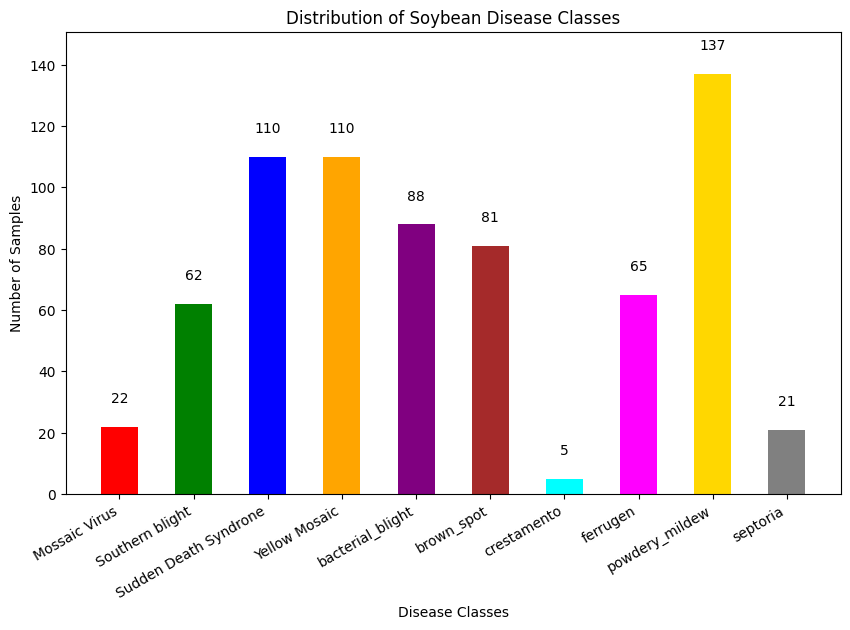

Distribution plot generated successfully.


In [13]:
unique_labels, label_counts = np.unique(All_labels, return_counts=True)
plt.figure(figsize=(10, 6))
colors = ['red','green','blue','orange','purple','brown','cyan','magenta','gold','gray']
plt.bar(unique_labels, label_counts, color=colors, width=0.5)
plt.xlabel('Disease Classes')
plt.ylabel('Number of Samples')
plt.title('Distribution of Soybean Disease Classes')
max_count = max(label_counts)
plt.ylim(0, max_count + 0.1 * max_count)
for i, count in enumerate(label_counts):
    plt.text(i, count + 0.05 * max_count, str(count), ha='center', va='bottom')
plt.xticks(rotation=30, ha='right')
plt.show()
print("Distribution plot generated successfully.")

# ****FPN**** 

In [14]:
# --- Simple FPN feature extractor (64x64x3 input) ---
def build_simple_fpn_feature_extractor(input_shape=(64, 64, 3), fpn_channels=64):
    x_in = layers.Input(shape=input_shape)

    # Backbone (your 3 conv blocks)
    x = layers.Conv2D(18, 3, padding='same', activation='relu')(x_in)  # C3 base
    c3 = layers.MaxPooling2D(2)(x)   # 32x32x18

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(c3)    # C4 base
    c4 = layers.MaxPooling2D(2)(x)   # 16x16x32

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(c4)    # C5 base
    c5 = layers.MaxPooling2D(2)(x)   #  8x8x64

    # Lateral 1x1 to unify channels
    l3 = layers.Conv2D(fpn_channels, 1, padding='same')(c3)  # 32x32xF
    l4 = layers.Conv2D(fpn_channels, 1, padding='same')(c4)  # 16x16xF
    l5 = layers.Conv2D(fpn_channels, 1, padding='same')(c5)  #  8x8xF

    # Top-down pathway (nearest upsample + add)
    p5 = l5
    p4 = layers.Add()([l4, layers.UpSampling2D(2)(p5)])      # 8->16
    p3 = layers.Add()([l3, layers.UpSampling2D(2)(p4)])      # 16->32

    # Light 3x3 refinement (optional but common in FPN)
    p3 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p3)
    p4 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p4)
    p5 = layers.Conv2D(fpn_channels, 3, padding='same', activation='relu')(p5)

    # Convert to one vector for SVM: GAP each level and concat
    g3 = layers.GlobalAveragePooling2D()(p3)   # -> (F,)
    g4 = layers.GlobalAveragePooling2D()(p4)   # -> (F,)
    g5 = layers.GlobalAveragePooling2D()(p5)   # -> (F,)
    feat_vec = layers.Concatenate(name="fpn_feat")([g3, g4, g5])  # -> (3F,)

    return models.Model(x_in, feat_vec, name="simple_fpn_feature_extractor")

# === Replace your previous model with this one ===
cnn_model = build_simple_fpn_feature_extractor(input_shape=(64,64,3), fpn_channels=64)
cnn_model.summary()
print("Model built successfully.")

Model: "simple_fpn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │        504 │ input_layer_1[0]… │
│                     │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │      5,216 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 8, 8, 64)  │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 8, 8, 64)  │      4,160 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │      2,112 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 16, 16,    │          0 │ conv2d_14[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 16, 16,    │          0 │ conv2d_13[0][0],  │
│                     │ 64)               │            │ up_sampling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │      1,216 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 32, 32,    │          0 │ add_2[0][0]       │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 32, 32,    │          0 │ conv2d_12[0][0],  │
│                     │ 64)               │            │ up_sampling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_3[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │     36,928 │ add_2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 8, 64)  │     36,928 │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 142,488 (556.59 KB)

 Trainable params: 142,488 (556.59 KB)

 Non-trainable params: 0 (0.00 B)

Model built successfully.


# Flattented Features

In [15]:
# Feature extraction (same usage pattern as your code)
train_features = cnn_model.predict(train_data, batch_size=64, verbose=0)
test_features  = cnn_model.predict(test_data,  batch_size=64, verbose=0)

# (Optional) L2 normalization helps SVMs
def l2_normalize(a, axis=1, eps=1e-12):
    return a / np.maximum(np.linalg.norm(a, axis=axis, keepdims=True), eps)

train_features = l2_normalize(train_features)
test_features  = l2_normalize(test_features)

# If you still want to "flatten" like before, it's already 2D (N, 3*fpn_channels).
# But this keeps compatibility with your original lines:
train_features_flattened = np.reshape(train_features, (train_features.shape[0], -1))
test_features_flattened  = np.reshape(test_features,  (test_features.shape[0], -1))

print("Feature extraction done successfully.")

Feature extraction done successfully.


# **RF**

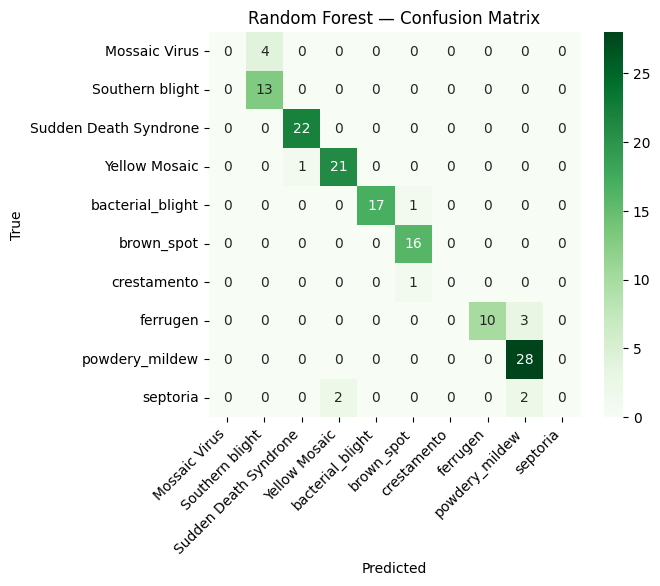

Random Forest — Classification Report
                        precision    recall  f1-score   support

        Mossaic Virus     0.0000    0.0000    0.0000         4
      Southern blight     0.7647    1.0000    0.8667        13
Sudden Death Syndrone     0.9565    1.0000    0.9778        22
        Yellow Mosaic     0.9130    0.9545    0.9333        22
     bacterial_blight     1.0000    0.9444    0.9714        18
           brown_spot     0.8889    1.0000    0.9412        16
          crestamento     0.0000    0.0000    0.0000         1
             ferrugen     1.0000    0.7692    0.8696        13
       powdery_mildew     0.8485    1.0000    0.9180        28
             septoria     0.0000    0.0000    0.0000         4

             accuracy                         0.9007       141
            macro avg     0.6372    0.6668    0.6478       141
         weighted avg     0.8514    0.9007    0.8714       141



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,           
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",      
    class_weight="balanced",  
    random_state=42,
    n_jobs=-1
)
rf_model.fit(train_features_flattened, train_labels)

rf_pred_labels = rf_model.predict(test_features_flattened)
rf_pred_probs  = rf_model.predict_proba(test_features_flattened)

rf_cm = confusion_matrix(test_labels, rf_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Random Forest — Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# 🧾 Report
print("Random Forest — Classification Report\n",
      classification_report(test_labels, rf_pred_labels, target_names=label_encoder.classes_,digits=4))

# **Multiclass ROC**

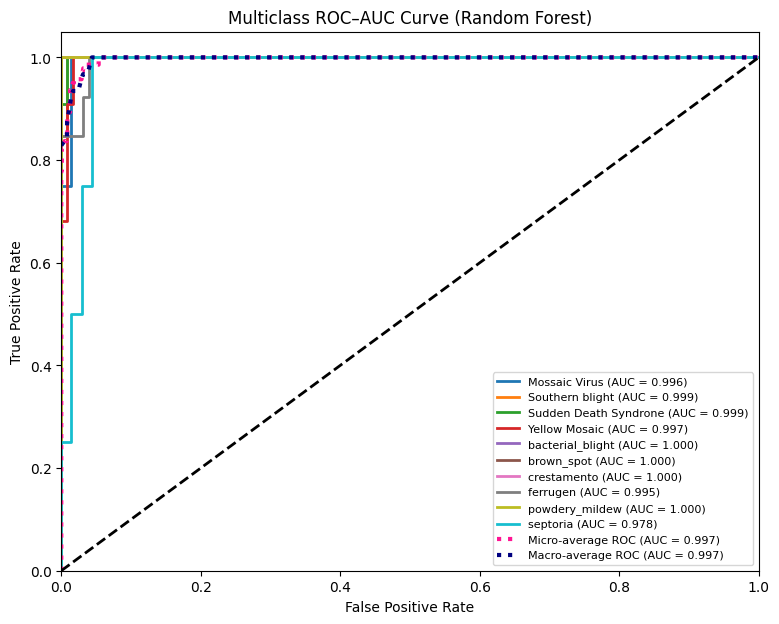

In [18]:
num_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(test_labels, classes=range(num_classes))
y_pred_proba = rf_pred_probs

fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(9,7))
colors = plt.cm.tab10.colors
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_name} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", linewidth=3,
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", linewidth=3,
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})")
plt.plot([0,1], [0,1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC–AUC Curve (Random Forest)")
plt.legend(loc="lower right", fontsize=8)
plt.show()

# **Analysis**

In [20]:
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 64

def load_images(dataset_path):
    X = []
    y = []

    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)

        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)

                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0

                X.append(img)
                y.append(class_name)

    return np.array(X), np.array(y)

dataset_path = "/kaggle/input/datasets/sivm205/soybean-diseased-leaf-dataset"
X, y = load_images(dataset_path)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(X.shape)
print(y_encoded.shape)

(701, 64, 64, 3)
(701,)


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier

fold_acc = []
fold_f1 = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_features, train_labels), 1):

    X_train = train_features[train_idx]
    X_val = train_features[val_idx]

    y_train = train_labels[train_idx]
    y_val = train_labels[val_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)

    acc = accuracy_score(y_val, y_pred) * 100
    f1 = f1_score(y_val, y_pred, average="weighted") * 100

    fold_acc.append(acc)
    fold_f1.append(f1)

results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy (%)": np.round(fold_acc, 2),
    "F1-Score (%)": np.round(fold_f1, 2)
})

results.loc[len(results)] = [
    "Average",
    f"{np.mean(fold_acc):.2f} ± {np.std(fold_acc):.2f}",
    f"{np.mean(fold_f1):.2f} ± {np.std(fold_f1):.2f}"
]

print(results.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


   Fold Accuracy (%) F1-Score (%)
      1        89.29        87.45
      2        89.29        87.41
      3        93.75        93.06
      4        89.29        86.04
      5        86.61        84.73
Average 89.64 ± 2.30 87.74 ± 2.84
